# Corridor Two-Body Kinematic Plausibility Simulation

Author: Stellars Henson<br>
Approach: minimum-phases analytical reconstruction of the contested 3-second two-body movement sequence, with kinematic demands scored against published biomechanical reference distributions.

## Cross-references

- `references/incident/geometry.md` - corridor topology, actor positions, props (briefcase, stroller, swung door panel), body-relative directions
- `references/incident/events_reconstruction.md` - minimum-viable stage reconstruction with ELBO-style methodology
- `references/incident/testimony_victim.md` - Victoria's five chronologically ordered accounts
- `references/incident/testimony_3rd_party.md` - court social curator's observations
- `references/incident/testimony_victoria_inconsistencies.md` - evolution of Victoria's narrative across five tellings
- `docs/impact_analysis.md` - impact-force consequences against thoracic-impact biomechanical literature

## Corrected geometry (summary)

Corridor runs W to E. Two segments:

- **Segment 1** (entrance, narrower) on the west; segment 2 (wider) on the east contains both doors
- **Apartment door** on the N wall of segment 2, opens to the W (~1 m wide panel projects into the corridor)
- **Elevator door** on the S wall of segment 2, slightly west of the apartment door
- **N-S distance** between the two doors: ~2 m (this is the throw distance)

At the contested moment:

- **Victoria** stands inside the apartment door envelope on its W side, facing S out into the corridor. Her body-relative left = E, right = W, front = S, back = N
- **Andrew** stands with his back pressed flat against the elevator door (S wall), facing N toward Victoria. Maximum-retreat position
- **Cecilia** stands in segment 1 west of both, facing E, overlooking segment 2 with a clear view of the apartment door area
- **[Box]** aluminium briefcase ~50 × 30 cm on the floor at the east edge of the elevator door, blocking Andrew's east step-out
- **[Str]** stroller in segment 2 NW corner
- **D** apartment door panel swung W into the corridor, partially obstructing Cecilia's eastward line of sight

## Methodology - minimum-phases reconstruction (ELBO-style lower bound)

This notebook computes a **lower bound** on the required kinematic demand using the smallest set of separable physical phases that maps the verbatim claim. No additional gestures, transitional pauses, hand re-positionings or body adjustments are added; each phase gets the maximum duration the 3 s budget allows, minimising the required peak velocity, acceleration and force.

Structurally identical to ELBO:

| Variational inference (ELBO) | Min-phases reconstruction |
|---|---|
| Tractable lower bound on $\log p(x)$ | Tractable lower bound on $D(M_{\text{true}})$ |
| Improving the bound never hurts the true | Violation of the bound implies violation of the true |

If $D_{\min}(q^\star) \gg R$ (lower-bound demand greatly exceeds the population reference $R$), then $D(M_{\text{true}}) \gg R$ too - regardless of how the actual motion is decomposed. Full derivation in `references/incident/events_reconstruction.md`.

## Scoring rubric

| z-score above reference mean | Verdict |
|---|---|
| z <= 1 | plausible |
| 1 < z <= 2 | strained |
| 2 < z <= 3 | implausible |
| z > 3 | extreme |

Worst-case cooperation model: Victoria is treated as fully passive (no resistive friction or grip). Adding any resistance only increases the actor's required force, so the passive model is a lower bound on the demand.


In [1]:
# Imports
from __future__ import annotations

import math  # standard library
from pathlib import Path

# Numerical / data
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Rich console for tabular output
from rich import print as rprint
from rich.console import Console
from rich.table import Table

# Project modules
from henryk_simulations.corridor import (
    PhaseResult,
    PlausibilityScore,
    Verdict,
    compute_scenario,
    default_library,
    default_scenario,
    score_phase,
)
from henryk_simulations.corridor.kinematics import (
    G,
    actor_effort_for_translation,
    compute_phase_kinematics,
)
from henryk_simulations.corridor.plausibility import (
    score_reach_phase,
    score_rotation_phase,
    score_translation_phase,
)
from henryk_simulations.corridor.plots import (
    plot_acceleration_over_time,
    plot_corridor_overhead,
    plot_force_over_time,
    plot_impulse_over_time,
    plot_per_phase_demand,
    plot_phase_timeline,
    plot_reference_overlay,
    plot_speed_over_time,
    plot_verdict_summary,
)

console = Console()
sns.set_theme(style="whitegrid", context="notebook")
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


2026-05-13 19:33:49.673 | INFO     | henryk_simulations.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/private/henryk/henryk-simulations


In [2]:
# Reproducibility - bootstrap CIs sample from references
SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)


## Configuration

In [3]:
# ============================================================================
# CONFIGURATION - single source of truth for every numeric knob in this
# notebook. Edit any value below and re-run from this cell down.
#
# PARAMS is a plain nested dict (JSON-serialisable), grouped by domain:
#   bodies     - masses, heights, yaw inertias
#   geometry   - corridor dimensions
#   phases     - per-phase durations and motion budgets
#   impact     - door collision parameters
# ============================================================================
import json

from rich import box
from rich.pretty import Pretty

from henryk_simulations.corridor.config import Bodies, Geometry, Phase, Scenario
from henryk_simulations.corridor.kinematics import MU_RESIST

PARAMS: dict = {
    "bodies": {
        "andrew": {
            "mass_kg":            90.0,
            "height_m":           1.80,
            "yaw_inertia_kgm2":   1.8,
        },
        "victoria": {
            "mass_kg":            70.0,
            "height_m":           1.68,
            "yaw_inertia_kgm2":   1.4,
        },
    },
    "geometry": {
        "corridor_width_m":       2.0,    # door-to-door (N-S)
        "corridor_lateral_m":     1.5,    # side wall to side wall (E-W within segment)
        "door_height_m":          2.1,
    },
    "phases": {
        # Kinematic peaks scale as v_peak = 2*s/t and a_peak = 4*s/t^2, so
        # shorter phases produce higher required peaks.
        "pull": {
            "duration_s":         1.0,
            "translation_m":      1.5,    # V's CoM moves toward elevator
            "rotation_rad":       0.0,
        },
        "swap-throw": {
            "duration_s":         1.0,
            "translation_m":      0.22,   # V's CoM final closing distance before impact
            "rotation_rad":       math.pi,
        },
        "swap-back": {
            "duration_s":         1.0,
            "rotation_rad":       math.pi,           # A rotates 180 deg
            "other_translation_m": 0.40,             # V steps back 40 cm
            "other_rotation_rad":  math.pi,          # V rotates 180 deg to keep facing A
        },
    },
    "impact": {
        "stopping_distance_cm":   2.0,    # V's torso travel while decelerating into door
    },
}

# --- Build the Scenario from PARAMS (the rest of the notebook reads from sc) ---
sc = Scenario(
    total_time=sum(p["duration_s"] for p in PARAMS["phases"].values()),
    geometry=Geometry(
        corridor_width=PARAMS["geometry"]["corridor_width_m"],
        corridor_lateral=PARAMS["geometry"]["corridor_lateral_m"],
        door_height=PARAMS["geometry"]["door_height_m"],
    ),
    bodies=Bodies(
        h_mass=PARAMS["bodies"]["andrew"]["mass_kg"],
        m_mass=PARAMS["bodies"]["victoria"]["mass_kg"],
        standing_height_h=PARAMS["bodies"]["andrew"]["height_m"],
        standing_height_m=PARAMS["bodies"]["victoria"]["height_m"],
        yaw_inertia_h=PARAMS["bodies"]["andrew"]["yaw_inertia_kgm2"],
        yaw_inertia_m=PARAMS["bodies"]["victoria"]["yaw_inertia_kgm2"],
    ),
    phases=(
        Phase(
            "pull",
            PARAMS["phases"]["pull"]["duration_s"],
            "translate", "M",
            translation=PARAMS["phases"]["pull"]["translation_m"],
            rotation=PARAMS["phases"]["pull"]["rotation_rad"],
        ),
        Phase(
            "swap-throw",
            PARAMS["phases"]["swap-throw"]["duration_s"],
            "translate", "M",
            translation=PARAMS["phases"]["swap-throw"]["translation_m"],
            rotation=PARAMS["phases"]["swap-throw"]["rotation_rad"],
        ),
        Phase(
            "swap-back",
            PARAMS["phases"]["swap-back"]["duration_s"],
            "rotate", "H",
            rotation=PARAMS["phases"]["swap-back"]["rotation_rad"],
            other_translation=PARAMS["phases"]["swap-back"]["other_translation_m"],
            other_rotation=PARAMS["phases"]["swap-back"]["other_rotation_rad"],
        ),
    ),
)
lib = default_library()

# --- Derived helpers ---
STOPPING_DISTANCE_CM = PARAMS["impact"]["stopping_distance_cm"]
STOPPING_DISTANCE_M  = STOPPING_DISTANCE_CM / 100.0

# --- Render PARAMS (single source of truth) and a quick summary ---
console.rule("[bold medium_purple]PARAMS (single source of truth)")
console.print(Pretty(PARAMS, expand_all=True))

summary = Table(
    title="Derived scenario",
    box=box.ROUNDED,
    show_header=True,
    header_style="bold medium_purple",
    title_justify="left",
    title_style="bold medium_purple",
)
summary.add_column("Quantity", style="bold")
summary.add_column("Value", justify="right")
summary.add_row("total time budget",       f"[light_sea_green]{sc.total_time:.2f} s[/light_sea_green]")
summary.add_row("phase count",             f"[dark_sea_green]{len(sc.phases)}[/dark_sea_green]")
summary.add_row("Andrew vs Victoria",      f"[light_sea_green]{sc.bodies.h_mass:.0f} kg[/light_sea_green] vs [light_sea_green]{sc.bodies.m_mass:.0f} kg[/light_sea_green]")
summary.add_row("corridor (door-to-door)", f"[light_sea_green]{sc.geometry.corridor_width:.2f} m[/light_sea_green]")
summary.add_row("impact stopping dist.",   f"[light_sea_green]{STOPPING_DISTANCE_CM:.1f} cm[/light_sea_green]")
summary.add_row("floor friction coef.",    f"[grey70]{MU_RESIST:.2f}[/grey70] [dim](from kinematics.MU_RESIST)[/dim]")
console.print(summary)


───────────────────────────────────────── PARAMS (single source of truth) ─────────────────────────────────────────

{
    'bodies': {
        'andrew': {
            'mass_kg': 90.0,
            'height_m': 1.8,
            'yaw_inertia_kgm2': 1.8
        },
        'victoria': {
            'mass_kg': 70.0,
            'height_m': 1.68,
            'yaw_inertia_kgm2': 1.4
        }
    },
    'geometry': {
        'corridor_width_m': 2.0,
        'corridor_lateral_m': 1.5,
        'door_height_m': 2.1
    },
    'phases': {
        'pull': {
            'duration_s': 1.0,
            'translation_m': 1.5,
            'rotation_rad': 0.0
        },
        'swap-throw': {
            'duration_s': 1.0,
            'translation_m': 0.22,
            'rotation_rad': 3.141592653589793
        },
        'swap-back': {
            'duration_s': 1.0,
            'rotation_rad': 3.141592653589793,
            'other_translation_m': 0.4,
            'other_rotation_rad': 3.141592653589793
        }
    },
    'impact': {
        'stopping_distance_cm': 2.0
    }
}

Derived scenario                                              
╭─────────────────────────┬──────────────────────────────────╮
│ Quantity                │                            Value │
├─────────────────────────┼──────────────────────────────────┤
│ total time budget       │                           3.00 s │
│ phase count             │                                3 │
│ Andrew vs Victoria      │                   90 kg vs 70 kg │
│ corridor (door-to-door) │                           2.00 m │
│ impact stopping dist.   │                           2.0 cm │
│ floor friction coef.    │ 0.30 (from kinematics.MU_RESIST) │
╰─────────────────────────┴──────────────────────────────────╯

/home/lab/workspace/private/henryk/henryk-simulations/src/henryk_simulations/corridor/plots.py:445: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  briefcase = mpatches.Rectangle(
/home/lab/workspace/private/henryk/henryk-simulations/src/henryk_simulations/corridor/plots.py:467: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  stroller = mpatches.Rectangle(


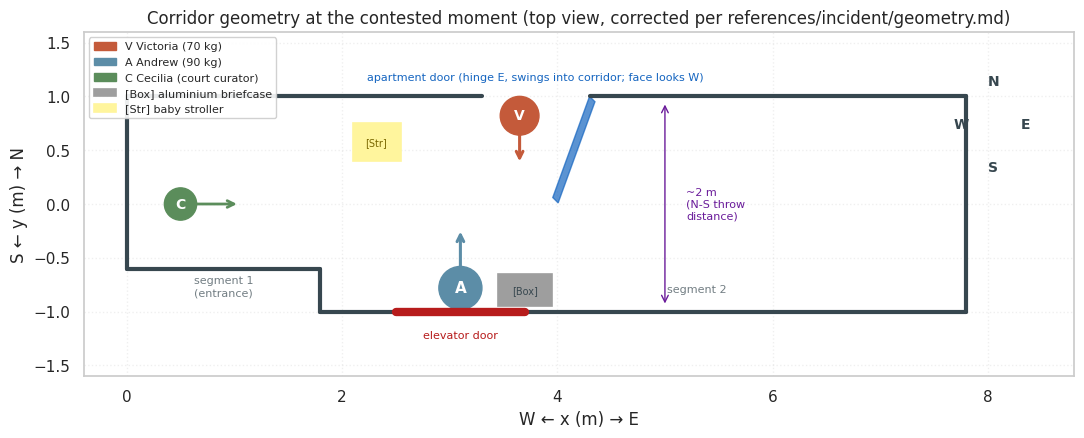

In [4]:
# Corridor overhead schematic
fig_corr = plot_corridor_overhead(
    sc.geometry,
    sc.bodies,
    out_path=FIG_DIR / "01-corridor-geometry.png",
)
plt.show()


## Phase decomposition

In [5]:
# Phase decomposition table
ph_table = Table(title="3-phase decomposition", show_header=True, header_style="bold")
for col in ("#", "phase", "kind", "body", "duration (s)", "translation (m)", "rotation (deg)", "notes"):
    ph_table.add_column(col)
notes_map = {
    "pull": "A retreats backward toward elevator pulling V along (1.5 m of V's 2 m total)",
    "swap-throw": "Positions exchange + V's back impacts elevator door + V rotates 180 deg tracking A",
    "swap-back": "Positions exchange back; A rotates 180 deg to face away (back to elevator); V rotates 180 deg",
}
for idx, phase in enumerate(sc.phases):
    deg = phase.rotation * 180 / math.pi if phase.rotation else 0
    ph_table.add_row(
        str(idx + 1),
        phase.name,
        phase.kind,
        phase.body,
        f"{phase.duration:.2f}",
        f"{phase.translation:.2f}" if phase.translation else "-",
        f"{deg:.0f}" if deg else "-",
        notes_map.get(phase.name, ""),
    )
console.print(ph_table)


                                               3-phase decomposition                                               
┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ # ┃ phase      ┃ kind      ┃ body ┃ duration (s) ┃ translation (m) ┃ rotation (deg) ┃ notes                     ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1 │ pull       │ translate │ M    │ 1.00         │ 1.50            │ -              │ A retreats backward       │
│   │            │           │      │              │                 │                │ toward elevator pulling V │
│   │            │           │      │              │                 │                │ along (1.5 m of V's 2 m   │
│   │            │           │      │              │                 │                │ total)                    │
│ 2 │ swap-throw │ translate │ M    │ 1.00         │ 0.22            │ 180            │ Positions exchange + V's  │
│   │            │           │      │              │                 │                │ back impacts elevator     │
│   │            │           │      │              │                 │                │ door + V rotates 180 deg  │
│   │            │           │      │              │                 │                │ tracking A                │
│ 3 │ swap-back  │ rotate    │ H    │ 1.00         │ -               │ 180            │ Positions exchange back;  │
│   │            │           │      │              │                 │                │ A rotates 180 deg to face │
│   │            │           │      │              │                 │                │ away (back to elevator);  │
│   │            │           │      │              │                 │                │ V rotates 180 deg         │
└───┴────────────┴───────────┴──────┴──────────────┴─────────────────┴────────────────┴───────────────────────────┘

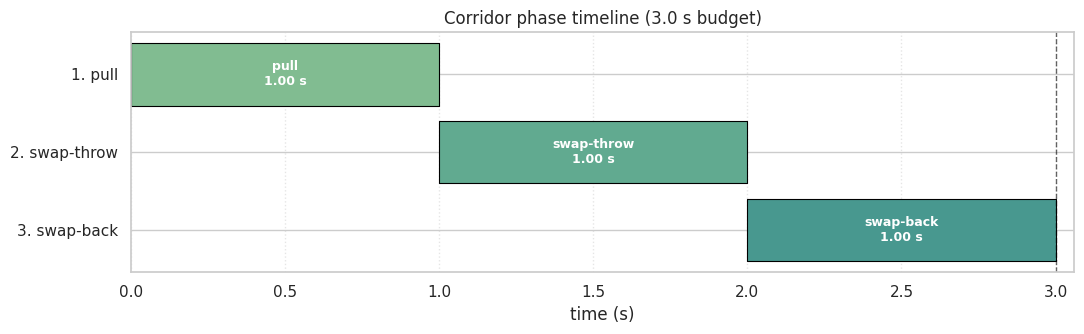

In [6]:
# Phase timeline gantt
fig_timeline = plot_phase_timeline(
    sc.phases,
    sc.phase_starts,
    total_time=sc.total_time,
    out_path=FIG_DIR / "01-phase-timeline.png",
)
plt.show()


## Kinematic demands per phase

In [7]:
# Per-phase kinematics (no-resistance / worst-case scenario)
rows = []
results = compute_scenario(sc, resistance="passive", impact_stopping_distance=STOPPING_DISTANCE_M)
for r in results:
    rows.append({
        "phase": r.phase_name,
        "kind": r.kind,
        "body": r.body,
        "mass_kg": r.mass,
        "duration_s": r.duration,
        "distance_m": r.distance,
        "v_start_m_s": round(r.v_start, 3),
        "v_end_m_s": round(r.v_end, 3),
        "v_peak_m_s": round(r.v_peak, 3),
        "a_avg_m_s2": round(r.a_avg, 3),
        "a_peak_m_s2": round(r.a_peak, 3),
        "a_peak_g": round(r.a_peak_g, 3),
        "f_avg_N": round(r.f_avg, 1),
        "f_peak_N": round(r.f_peak, 1),
        "impulse_net_N_s": round(r.impulse_net, 1),
        "ke_start_J": round(r.ke_start, 1),
        "ke_end_J": round(r.ke_end, 1),
        "ke_J": round(r.kinetic_energy, 1),
        "work_done_J": round(r.work_done, 1),
        "omega_peak_rad_s": round(r.omega_peak, 3),
        "alpha_peak_rad_s2": round(r.alpha_peak, 3),
        "torque_peak_Nm": round(r.torque_peak, 1),
        "rot_ke_J": round(r.rotational_ke, 1),
    })
results_df = pd.DataFrame(rows)
results_df.head(20)


,phase,kind,body,mass_kg,duration_s,distance_m,v_start_m_s,v_end_m_s,v_peak_m_s,a_avg_m_s2,...,f_peak_N,impulse_net_N_s,ke_start_J,ke_end_J,ke_J,work_done_J,omega_peak_rad_s,alpha_peak_rad_s2,torque_peak_Nm,rot_ke_J
0,pull,translate,M,70.0,1.0,1.50,0.0,3.0,3.00,3.0,...,420.0,210.0,0.0,315.0,315.0,315.0,0.000,0.000,0.0,0.0
1,swap-throw,translate,M,70.0,1.0,0.22,3.0,0.0,0.44,-3.0,...,61.6,-210.0,315.0,0.0,6.8,-315.0,6.283,12.566,17.6,27.6
2,swap-back,rotate,H,90.0,1.0,0.00,0.0,0.0,0.00,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,6.283,12.566,22.6,35.5
3,swap-back/M,translate,M,70.0,1.0,0.40,0.0,0.8,0.80,0.8,...,112.0,56.0,0.0,22.4,22.4,22.4,6.283,12.566,17.6,27.6


In [8]:
# Full per-phase deconstruction: triangular-peak quantities + continuous-velocity
# model + rotation kinematics + impact analysis (where applicable).
all_results = compute_scenario(sc, resistance="passive", impact_stopping_distance=STOPPING_DISTANCE_M)

# --- Continuous-velocity translation (v_start, v_end, a_avg, F_avg, impulse, KE) ---
cv_table = Table(
    title="Translation kinematics per phase (continuous-velocity model)",
    show_header=True, header_style="bold",
)
for col in ("phase", "T (s)", "s (m)",
            "v_start (m/s)", "v_end (m/s)",
            "a_avg (m/s²)", "a_avg (g)",
            "F_avg (N)",
            "impulse (N·s)",
            "KE_start (J)", "KE_end (J)", "work (J)"):
    cv_table.add_column(col)
for r in all_results:
    if r.kind != "translate":
        cv_table.add_row(
            r.phase_name, f"{r.duration:.2f}", "-",
            f"{r.v_start:.2f}", f"{r.v_end:.2f}",
            "-", "-", "-", "-", "-", "-", "-",
        )
        continue
    cv_table.add_row(
        r.phase_name,
        f"{r.duration:.2f}",
        f"{r.distance:.2f}",
        f"{r.v_start:.2f}",
        f"{r.v_end:.2f}",
        f"{r.a_avg:+.2f}",
        f"{r.a_avg / 9.80665:+.2f}",
        f"{r.f_avg:.0f}",
        f"{r.impulse_net:+.0f}",
        f"{r.ke_start:.0f}",
        f"{r.ke_end:.0f}",
        f"{r.work_done:+.0f}",
    )
console.print(cv_table)

# --- Triangular-peak quantities (a_peak, F_peak, KE_at_peak) ---
peak_table = Table(
    title="Translation peaks per phase (triangular profile within phase)",
    show_header=True, header_style="bold",
)
for col in ("phase", "v_peak (m/s)", "a_peak (m/s²)", "a_peak (g)",
            "F_peak (N)", "KE_peak (J)", "impulse_accel (N·s)"):
    peak_table.add_column(col)
for r in all_results:
    if not r.v_peak:
        peak_table.add_row(r.phase_name, "-", "-", "-", "-", "-", "-")
        continue
    peak_table.add_row(
        r.phase_name,
        f"{r.v_peak:.2f}",
        f"{r.a_peak:.2f}",
        f"{r.a_peak_g:.2f}",
        f"{r.f_peak:.0f}",
        f"{r.kinetic_energy:.0f}",
        f"{r.impulse:.0f}",
    )
console.print(peak_table)

# --- Rotation kinematics ---
rot_table = Table(
    title="Rotation kinematics per phase",
    show_header=True, header_style="bold",
)
for col in ("phase", "T (s)", "θ (deg)",
            "ω_peak (rad/s)", "ω_peak (deg/s)",
            "α_peak (rad/s²)",
            "τ_peak (N·m)",
            "L_peak (kg·m²/s)",
            "rotational KE (J)"):
    rot_table.add_column(col)
for r in all_results:
    if not r.omega_peak:
        rot_table.add_row(r.phase_name, f"{r.duration:.2f}", "-", "-", "-", "-", "-", "-", "-")
        continue
    rot_table.add_row(
        r.phase_name,
        f"{r.duration:.2f}",
        f"{r.angle * 180 / math.pi:.0f}",
        f"{r.omega_peak:.2f}",
        f"{r.omega_peak * 180 / math.pi:.0f}",
        f"{r.alpha_peak:.2f}",
        f"{r.torque_peak:.1f}",
        f"{r.angular_momentum_peak:.2f}",
        f"{r.rotational_ke:.1f}",
    )
console.print(rot_table)

# --- Impact analysis (only for phases where an impact is computed) ---
impacts = [r for r in all_results if r.impact is not None and r.impact.v_impact > 0]
if impacts:
    imp_table = Table(
        title="Impact analysis (constant-decel over stopping distance)",
        show_header=True, header_style="bold",
    )
    for col in ("phase", "v_impact (m/s)", "v_impact (km/h)",
                "stopping d (cm)",
                "KE_impact (J)",
                "momentum (N·s)",
                "a_impact (m/s²)", "a_impact (g)",
                "F_impact (N)", "F_impact (kN)",
                "t_stop (ms)"):
        imp_table.add_column(col)
    for r in impacts:
        i = r.impact
        imp_table.add_row(
            r.phase_name,
            f"{i.v_impact:.2f}",
            f"{i.v_impact * 3.6:.1f}",
            f"{i.stopping_distance * 100:.1f}",
            f"{i.ke_impact:.0f}",
            f"{i.momentum:.0f}",
            f"{i.a_impact:.0f}",
            f"{i.a_impact_g:.1f}",
            f"{i.f_impact:.0f}",
            f"{i.f_impact / 1000:.2f}",
            f"{i.t_stop * 1000:.1f}",
        )
    console.print(imp_table)


                           Translation kinematics per phase (continuous-velocity model)                            
┏━━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┓
┃         ┃       ┃       ┃ v_start ┃ v_end   ┃ a_avg   ┃ a_avg   ┃ F_avg   ┃ impul… ┃ KE_sta… ┃ KE_end ┃ work    ┃
┃ phase   ┃ T (s) ┃ s (m) ┃ (m/s)   ┃ (m/s)   ┃ (m/s²)  ┃ (g)     ┃ (N)     ┃ (N·s)  ┃ (J)     ┃ (J)    ┃ (J)     ┃
┡━━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━┩
│ pull    │ 1.00  │ 1.50  │ 0.00    │ 3.00    │ +3.00   │ +0.31   │ 210     │ +210   │ 0       │ 315    │ +315    │
│ swap-t… │ 1.00  │ 0.22  │ 3.00    │ 0.00    │ -3.00   │ -0.31   │ 210     │ -210   │ 315     │ 0      │ -315    │
│ swap-b… │ 1.00  │ -     │ 0.00    │ 0.00    │ -       │ -       │ -       │ -      │ -       │ -      │ -       │
│ swap-b… │ 1.00  │ 0.40  │ 0.00    │ 0.80    │ +0.80   │ +0.08   │ 56      │ +56    │ 0       │ 22     │ +22     │
└─────────┴───────┴───────┴─────────┴─────────┴─────────┴─────────┴─────────┴────────┴─────────┴────────┴─────────┘

                       Translation peaks per phase (triangular profile within phase)                        
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓
┃ phase       ┃ v_peak (m/s) ┃ a_peak (m/s²) ┃ a_peak (g) ┃ F_peak (N) ┃ KE_peak (J) ┃ impulse_accel (N·s) ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩
│ pull        │ 3.00         │ 6.00          │ 0.61       │ 420        │ 315         │ 210                 │
│ swap-throw  │ 0.44         │ 0.88          │ 0.09       │ 62         │ 7           │ 31                  │
│ swap-back   │ -            │ -             │ -          │ -          │ -           │ -                   │
│ swap-back/M │ 0.80         │ 1.60          │ 0.16       │ 112        │ 22          │ 56                  │
└─────────────┴──────────────┴───────────────┴────────────┴────────────┴─────────────┴─────────────────────┘

                                           Rotation kinematics per phase                                           
┏━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━┓
┃             ┃       ┃         ┃ ω_peak      ┃ ω_peak      ┃ α_peak      ┃ τ_peak     ┃ L_peak      ┃ rotational ┃
┃ phase       ┃ T (s) ┃ θ (deg) ┃ (rad/s)     ┃ (deg/s)     ┃ (rad/s²)    ┃ (N·m)      ┃ (kg·m²/s)   ┃ KE (J)     ┃
┡━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━┩
│ pull        │ 1.00  │ -       │ -           │ -           │ -           │ -          │ -           │ -          │
│ swap-throw  │ 1.00  │ 180     │ 6.28        │ 360         │ 12.57       │ 17.6       │ 8.80        │ 27.6       │
│ swap-back   │ 1.00  │ 180     │ 6.28        │ 360         │ 12.57       │ 22.6       │ 11.31       │ 35.5       │
│ swap-back/M │ 1.00  │ 180     │ 6.28        │ 360         │ 12.57       │ 17.6       │ 8.80        │ 27.6       │
└─────────────┴───────┴─────────┴─────────────┴─────────────┴─────────────┴────────────┴─────────────┴────────────┘

                              Impact analysis (constant-decel over stopping distance)                              
┏━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┓
┃         ┃ v_impa… ┃ v_impa… ┃ stopping ┃ KE_imp… ┃ momentum ┃ a_impa… ┃ a_impact ┃ F_impa… ┃ F_impact ┃ t_stop  ┃
┃ phase   ┃ (m/s)   ┃ (km/h)  ┃ d (cm)   ┃ (J)     ┃ (N·s)    ┃ (m/s²)  ┃ (g)      ┃ (N)     ┃ (kN)     ┃ (ms)    ┃
┡━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━┩
│ swap-t… │ 3.21    │ 11.6    │ 2.0      │ 361     │ 225      │ 258     │ 26.3     │ 18060   │ 18.06    │ 12.5    │
└─────────┴─────────┴─────────┴──────────┴─────────┴──────────┴─────────┴──────────┴─────────┴──────────┴─────────┘

In [9]:
# Actor effort and friction cap during the pull phase
throw = next(r for r in compute_scenario(sc, resistance="passive") if r.phase_name == "pull")
eff = actor_effort_for_translation(throw, actor_mass=sc.bodies.h_mass)
feasible_color = "dark_sea_green" if eff["feasible"] else "indian_red"
rprint(
    "[bold medium_purple]Actor effort budget[/bold medium_purple]\n"
    f"  required force on M : [light_sea_green]{eff['f_required_N']:.0f} N[/light_sea_green]\n"
    f"  friction cap (H mass [light_sea_green]{sc.bodies.h_mass:.0f} kg[/light_sea_green], "
    f"mu [grey70]{MU_RESIST:.2f}[/grey70]): [light_sea_green]{eff['f_friction_cap_N']:.0f} N[/light_sea_green]\n"
    f"  feasible            : [{feasible_color}]{eff['feasible']}[/{feasible_color}]\n"
    f"  headroom ratio      : [dark_sea_green]{eff['headroom_ratio']:.2f}[/dark_sea_green]"
)


Actor effort budget
  required force on M : 420 N
  friction cap (H mass 90 kg, mu 0.30): 265 N
  feasible            : False
  headroom ratio      : 0.63

## Reference distributions

In [10]:
# Reference distributions
ref_rows = []
for key, ref in lib.refs.items():
    lo, hi = ref.ci(0.95)
    ref_rows.append({
        "key": key,
        "name": ref.name,
        "units": ref.units,
        "mean": round(ref.mean, 3),
        "sd": round(ref.sd, 3),
        "ci95_lo": round(lo, 3),
        "ci95_hi": round(hi, 3),
        "population": ref.population,
        "citation": ref.citation,
    })
ref_df = pd.DataFrame(ref_rows)
ref_df


,key,name,units,mean,sd,ci95_lo,ci95_hi,population,citation
0,push_force_single_arm,"single-arm peak push, untrained male",N,400.0,100.0,204.004,595.996,"adult male, recreational",Daams 1994; Mital & Kumar 1995
1,push_force_two_arm,"two-arm peak push, standing",N,800.0,200.0,408.007,1191.993,"adult male, recreational",Daams 1994; Chaffin & Andersson 1991
2,sprint_acceleration_recreational,"sprint acceleration, recreational",m/s^2,3.0,0.8,1.432,4.568,"adult male, recreational","Mero, Komi & Gregor 1992; di Prampero 2005"
3,sprint_acceleration_elite,"sprint acceleration, elite sprinter",m/s^2,5.0,0.5,4.020,5.980,elite male sprinter,"Mero, Komi & Gregor 1992"
4,throw_velocity_object_5kg,"overhand throw velocity, 5 kg object",m/s,8.0,2.5,3.100,12.900,"adult male, recreational",Cross 2004; Atwater 1979
5,throw_kinetic_energy,"overhand throw KE budget, 5 kg object",J,160.0,80.0,3.203,316.797,"adult male, recreational",Cross 2004; van den Tillaar & Ettema 2004
6,yaw_angular_velocity_pivot,standing pivot yaw angular velocity,rad/s,3.5,1.0,1.540,5.460,"adult male, recreational","Hodgson, Lewis & Drury 2008"
7,whole_body_yaw_inertia,whole-body yaw moment of inertia,kg*m^2,1.5,0.4,0.716,2.284,"adult male, recreational","Plagenhoef, Evans & Abdelnour 1983"
8,arm_swing_velocity,arm swing forward velocity,m/s,2.5,0.8,0.932,4.068,"adult male, recreational","Marteniuk, MacKenzie & Leavitt 1990"


## Plausibility scoring

In [11]:
# Score each phase against the most appropriate reference for each kinematic demand
results_passive = compute_scenario(sc, resistance="passive", impact_stopping_distance=STOPPING_DISTANCE_M)

# Map phase -> chosen references. A translate phase that also has a rotation
# (Victoria's 360 deg yaw during the throw) is scored for both quantities.
def score_all(results):
    scores: list[PlausibilityScore] = []
    for r in results:
        if r.kind == "translate" and r.f_peak > 0:
            scores += score_translation_phase(
                r,
                accel_ref=lib["sprint_acceleration_recreational"],
                force_ref=lib["push_force_two_arm"],
                energy_ref=lib["throw_kinetic_energy"] if r.phase_name in ("pull", "swap-throw") else None,
            )
        if r.omega_peak > 0:
            scores += score_rotation_phase(r, omega_ref=lib["yaw_angular_velocity_pivot"])
        if r.kind == "reach" and r.reach_v_peak > 0:
            scores += score_reach_phase(r, arm_ref=lib["arm_swing_velocity"])
    return scores

scores = score_all(results_passive)
score_df = pd.DataFrame([
    {
        "phase": s.phase_name,
        "quantity": s.quantity_label,
        "required": round(s.required_value, 3),
        "units": s.units,
        "ref": s.reference_name,
        "ref_mean": round(s.reference_mean, 3),
        "ref_sd": round(s.reference_sd, 3),
        "z": round(s.z, 2),
        "x_mean": round(s.multiple_of_mean, 2),
        "verdict": s.verdict.value,
    }
    for s in scores
])
score_df


,phase,quantity,required,units,ref,ref_mean,ref_sd,z,x_mean,verdict
0,pull,peak acceleration,6.000,m/s^2,"sprint acceleration, recreational",3.0,0.8,3.75,2.00,extreme
1,pull,peak force,420.000,N,"two-arm peak push, standing",800.0,200.0,-1.90,0.53,plausible
2,pull,kinetic energy,315.000,J,"overhand throw KE budget, 5 kg object",160.0,80.0,1.94,1.97,strained
3,swap-throw,peak acceleration,0.880,m/s^2,"sprint acceleration, recreational",3.0,0.8,-2.65,0.29,plausible
4,swap-throw,peak force,61.600,N,"two-arm peak push, standing",800.0,200.0,-3.69,0.08,plausible
5,swap-throw,kinetic energy,6.776,J,"overhand throw KE budget, 5 kg object",160.0,80.0,-1.92,0.04,plausible
6,swap-throw,peak yaw angular velocity,6.283,rad/s,standing pivot yaw angular velocity,3.5,1.0,2.78,1.80,implausible
7,swap-back,peak yaw angular velocity,6.283,rad/s,standing pivot yaw angular velocity,3.5,1.0,2.78,1.80,implausible
8,swap-back/M,peak acceleration,1.600,m/s^2,"sprint acceleration, recreational",3.0,0.8,-1.75,0.53,plausible
9,swap-back/M,peak force,112.000,N,"two-arm peak push, standing",800.0,200.0,-3.44,0.14,plausible


In [12]:
# Per-phase summary table: peak values + verdict bands per (phase, quantity)
summary_table = Table(
    title="Per-phase peak demands and verdicts",
    show_header=True,
    header_style="bold medium_purple",
)
for col in ("phase", "quantity", "required", "ref mean +/- sd", "x mean", "z", "verdict"):
    summary_table.add_column(col)

verdict_style = {
    "plausible":   "dark_sea_green",
    "strained":    "dark_goldenrod",
    "implausible": "indian_red",
    "extreme":     "bold indian_red",
}
for s in scores:
    summary_table.add_row(
        s.phase_name,
        s.quantity_label,
        f"[light_sea_green]{s.required_value:,.2f} {s.units}[/light_sea_green]",
        f"[grey70]{s.reference_mean:.2f} +/- {s.reference_sd:.2f} {s.units}[/grey70]",
        f"[dark_sea_green]{s.multiple_of_mean:.2f} x[/dark_sea_green]",
        f"[dark_sea_green]{s.z:+.2f}[/dark_sea_green]",
        f"[{verdict_style.get(s.verdict.value, 'white')}]{s.verdict.value}[/]",
    )
console.print(summary_table)


                                     Per-phase peak demands and verdicts                                     
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━┓
┃ phase       ┃ quantity                  ┃ required   ┃ ref mean +/- sd     ┃ x mean ┃ z     ┃ verdict     ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━┩
│ pull        │ peak acceleration         │ 6.00 m/s^2 │ 3.00 +/- 0.80 m/s^2 │ 2.00 x │ +3.75 │ extreme     │
│ pull        │ peak force                │ 420.00 N   │ 800.00 +/- 200.00 N │ 0.53 x │ -1.90 │ plausible   │
│ pull        │ kinetic energy            │ 315.00 J   │ 160.00 +/- 80.00 J  │ 1.97 x │ +1.94 │ strained    │
│ swap-throw  │ peak acceleration         │ 0.88 m/s^2 │ 3.00 +/- 0.80 m/s^2 │ 0.29 x │ -2.65 │ plausible   │
│ swap-throw  │ peak force                │ 61.60 N    │ 800.00 +/- 200.00 N │ 0.08 x │ -3.69 │ plausible   │
│ swap-throw  │ kinetic energy            │ 6.78 J     │ 160.00 +/- 80.00 J  │ 0.04 x │ -1.92 │ plausible   │
│ swap-throw  │ peak yaw angular velocity │ 6.28 rad/s │ 3.50 +/- 1.00 rad/s │ 1.80 x │ +2.78 │ implausible │
│ swap-back   │ peak yaw angular velocity │ 6.28 rad/s │ 3.50 +/- 1.00 rad/s │ 1.80 x │ +2.78 │ implausible │
│ swap-back/M │ peak acceleration         │ 1.60 m/s^2 │ 3.00 +/- 0.80 m/s^2 │ 0.53 x │ -1.75 │ plausible   │
│ swap-back/M │ peak force                │ 112.00 N   │ 800.00 +/- 200.00 N │ 0.14 x │ -3.44 │ plausible   │
│ swap-back/M │ peak yaw angular velocity │ 6.28 rad/s │ 3.50 +/- 1.00 rad/s │ 1.80 x │ +2.78 │ implausible │
└─────────────┴───────────────────────────┴────────────┴─────────────────────┴────────┴───────┴─────────────┘

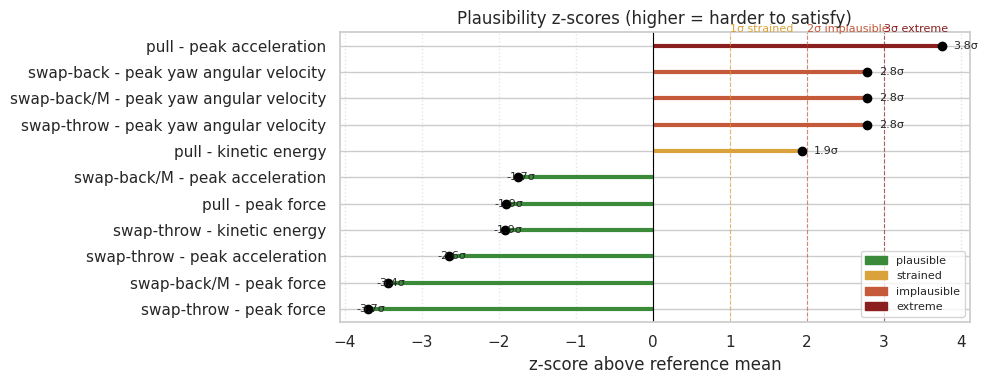

In [13]:
# Lollipop summary of z-scores
fig_verdict = plot_verdict_summary(scores, out_path=FIG_DIR / "01-verdict-summary.png")
plt.show()


## Visualisations

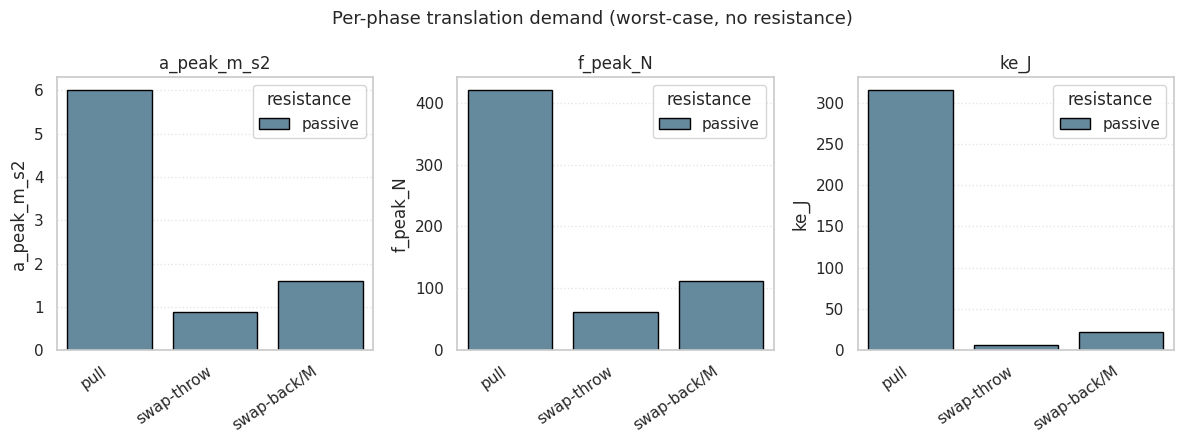

In [14]:
# Per-phase translation demand (worst-case, no resistance)
demand_df = results_df[results_df["a_peak_m_s2"] > 0].copy()
demand_df["resistance"] = "passive"
fig_demand = plot_per_phase_demand(
    demand_df,
    columns=["a_peak_m_s2", "f_peak_N", "ke_J"],
    out_path=FIG_DIR / "01-per-phase-demand.png",
    title="Per-phase translation demand (worst-case, no resistance)",
)
plt.show()


## Time-series: speed, acceleration, force, impulse

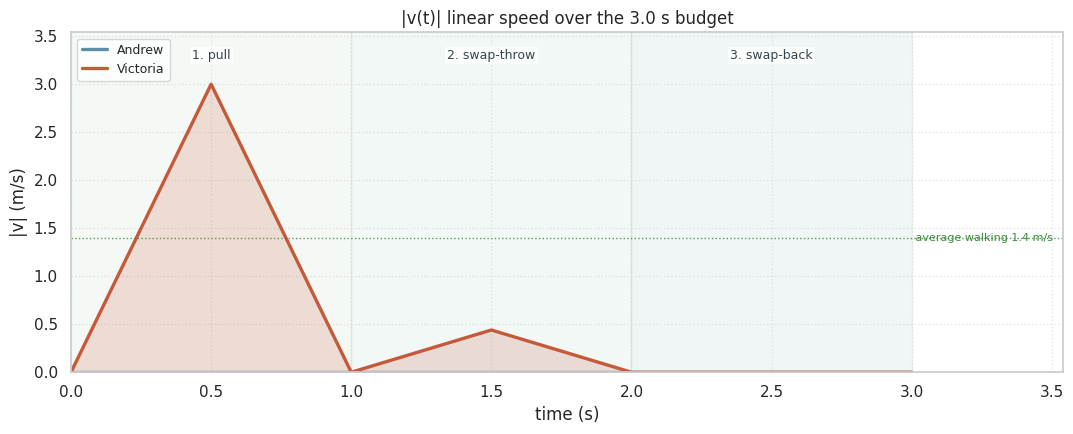

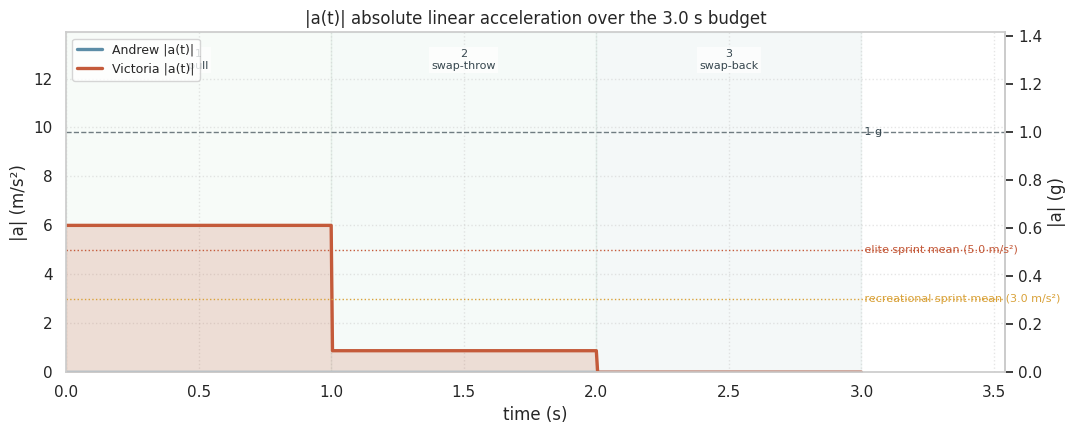

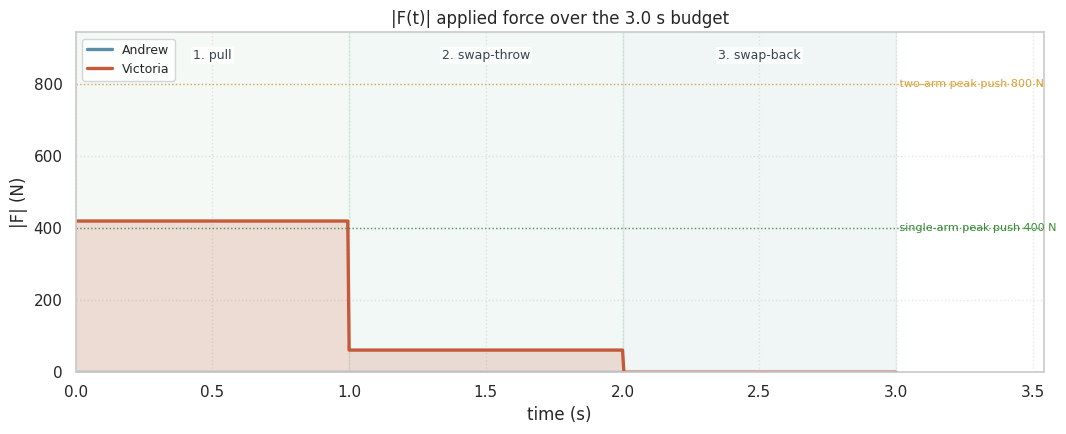

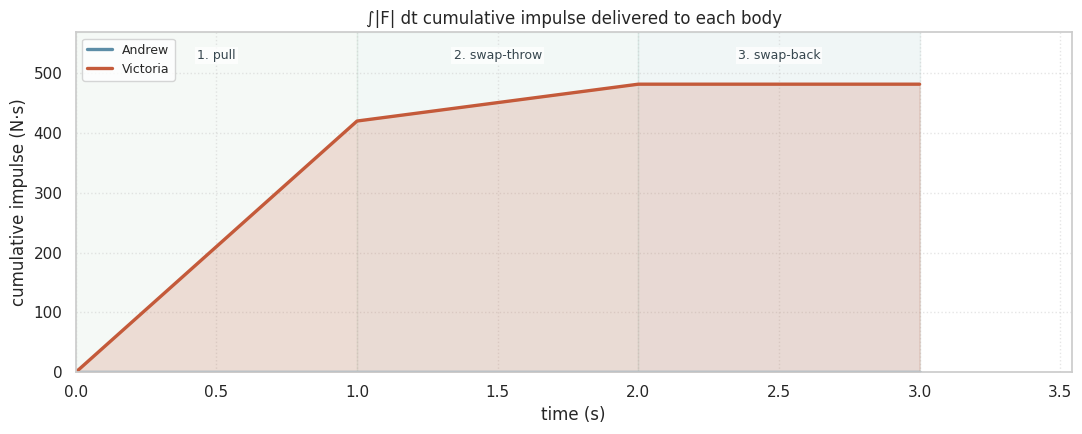

In [15]:
# Four time-series plots: speed, acceleration, force, cumulative impulse
fig_v = plot_speed_over_time(
    sc, results_passive, out_path=FIG_DIR / "01-speed-timeline.png"
)
plt.show()

fig_accel = plot_acceleration_over_time(
    sc, results_passive, out_path=FIG_DIR / "01-acceleration-timeline.png"
)
plt.show()

fig_F = plot_force_over_time(
    sc, results_passive, out_path=FIG_DIR / "01-force-timeline.png"
)
plt.show()

fig_p = plot_impulse_over_time(
    sc, results_passive, out_path=FIG_DIR / "01-impulse-timeline.png"
)
plt.show()


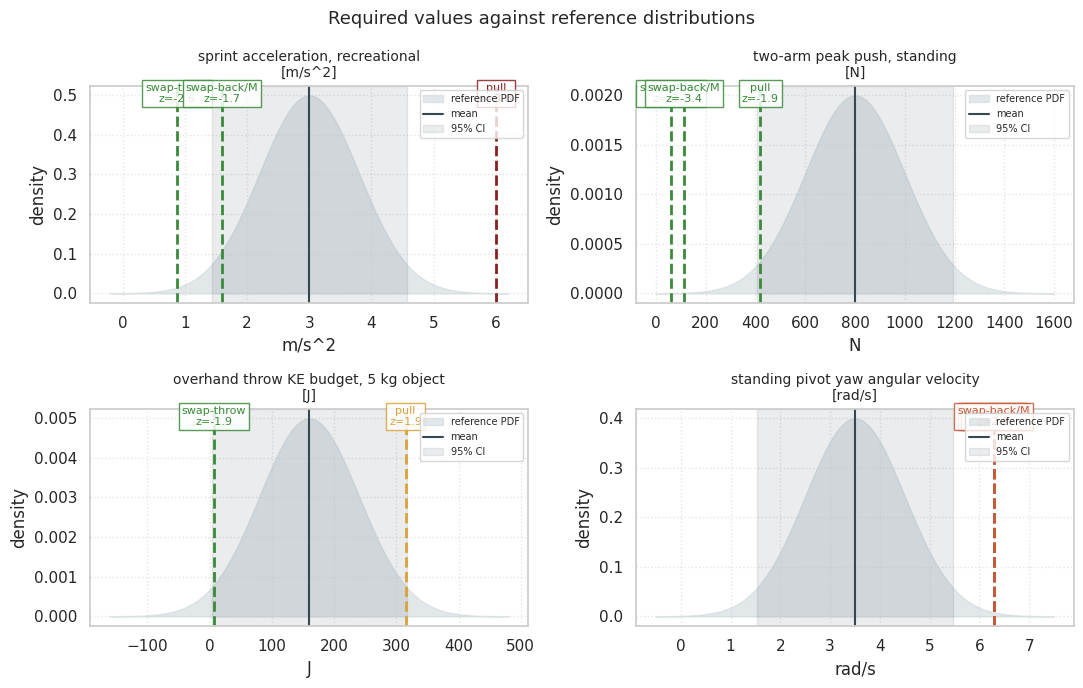

In [16]:
# Required values overlaid on reference distributions
# Pick the union of references that received at least one score
ref_used = []
for s in scores:
    if not any(r.name == s.reference_name for r in ref_used):
        ref_used.append(next(r for r in lib.refs.values() if r.name == s.reference_name))
fig_overlay = plot_reference_overlay(
    scores,
    ref_used,
    out_path=FIG_DIR / "01-reference-overlay.png",
)
plt.show()


## Throw energy budget

In [17]:
# Energy budget for the pull phase (largest translational demand)
throw_r = next(r for r in results_passive if r.phase_name == "pull")
push_budget_two_arm = lib["push_force_two_arm"].mean
throw_ke_ref = lib["throw_kinetic_energy"]

rprint(
    "[bold medium_purple]Throw energy budget[/bold medium_purple]\n"
    f"  kinetic energy delivered to M     : [light_sea_green]{throw_r.kinetic_energy:,.0f} J[/light_sea_green]\n"
    f"  reference for 5 kg overhand throw : "
    f"[grey70]{throw_ke_ref.mean:.0f} +/- {throw_ke_ref.sd:.0f} J[/grey70]\n"
    f"  multiple of reference mean        : "
    f"[dark_sea_green]{throw_r.kinetic_energy / throw_ke_ref.mean:.1f} x[/dark_sea_green]\n"
    f"  z-score above reference mean      : "
    f"[dark_sea_green]{throw_ke_ref.z(throw_r.kinetic_energy):.1f}[/dark_sea_green]\n"
    f"  force required (Newton 2nd law)   : [light_sea_green]{throw_r.f_peak:,.0f} N[/light_sea_green]\n"
    f"  two-arm push budget (Daams 1994)  : [light_sea_green]{push_budget_two_arm:,.0f} N[/light_sea_green]"
)


Throw energy budget
  kinetic energy delivered to M     : 315 J
  reference for 5 kg overhand throw : 160 +/- 80 J
  multiple of reference mean        : 2.0 x
  z-score above reference mean      : 1.9
  force required (Newton 2nd law)   : 420 N
  two-arm push budget (Daams 1994)  : 800 N

## Verdict tally and export

In [18]:
# Final verdict tally and export of the result table for the markdown report
verdict_counts = score_df["verdict"].value_counts().to_dict()
verdict_palette = {
    "plausible":   "dark_sea_green",
    "strained":    "dark_goldenrod",
    "implausible": "indian_red",
    "extreme":     "bold indian_red",
}

tally_lines = ["[bold medium_purple]Verdict tally across all (phase, quantity) scores[/bold medium_purple]"]
for v in ("plausible", "strained", "implausible", "extreme"):
    n = verdict_counts.get(v, 0)
    tally_lines.append(f"  [{verdict_palette[v]}]{v:14s}[/]: [dark_sea_green]{n}[/dark_sea_green]")

implausible_or_worse = score_df[score_df["verdict"].isin(["implausible", "extreme"])]
tally_lines.append(
    f"\n[bold medium_purple]Implausible or extreme phases (z > 2):[/bold medium_purple] "
    f"[indian_red]{len(implausible_or_worse)}[/indian_red]"
)
rprint("\n".join(tally_lines))
console.print(
    implausible_or_worse[["phase", "quantity", "required", "ref_mean", "z", "verdict"]].to_string(index=False)
)

# Persist for the verdict report
score_df.to_csv(FIG_DIR.parent / "01-phase-scores.csv", index=False)
results_df.to_csv(FIG_DIR.parent / "01-phase-kinematics.csv", index=False)


Verdict tally across all (phase, quantity) scores
  plausible     : 6
  strained      : 1
  implausible   : 3
  extreme       : 1

Implausible or extreme phases (z > 2): 4

phase                  quantity  required  ref_mean    z     verdict
       pull         peak acceleration     6.000       3.0 3.75     extreme
 swap-throw peak yaw angular velocity     6.283       3.5 2.78 implausible
  swap-back peak yaw angular velocity     6.283       3.5 2.78 implausible
swap-back/M peak yaw angular velocity     6.283       3.5 2.78 implausible

## Conclusions: simulation outputs vs human-injury thresholds

The plausibility scoring above answers whether the *motion itself* sits inside or outside the population's biomechanical envelope. Here we go one step further and ask the medical question: given the impact force, peak acceleration, kinetic energy and impact velocity the reconstruction produces, what tissue-level damage would these magnitudes be predicted to cause?

### Continued acceleration through swap-throw

The actor (Andrew) does not release V at the moment of door contact; the throw is sustained through the closing distance. The model in `compute_scenario` therefore treats the acceleration built during the pull phase as **continuing through the swap-throw 0.22 m closing distance**, so V hits the door at her **peak velocity**:

$$v_\text{impact}^2 \;=\; v_\text{pull-end}^2 \;+\; 2\, a_\text{pull}\, s_\text{swap}, \qquad a_\text{pull} \;=\; \frac{2\, s_\text{pull}}{t_\text{pull}^2}$$

With the default knobs ($s_\text{pull}=1.5$ m, $t_\text{pull}=1.0$ s, $s_\text{swap}=0.22$ m):

$$v_\text{impact} \;=\; \sqrt{3.0^2 + 2 \cdot 3.0 \cdot 0.22} \;\approx\; 3.21\ \text{m/s} \;\approx\; 11.6\ \text{kph}$$

That peak velocity is then decelerated to zero over the 2 cm stopping distance at the door. Plug into $a = v^2/(2d)$ and $F = m a$ for V's 70 kg torso:

$$a_\text{impact} \;=\; \frac{3.21^2}{2 \cdot 0.02} \;\approx\; 258\ \text{m/s}^2 \;\approx\; 26\, g, \qquad F_\text{impact} \;=\; m \cdot a \;\approx\; 18\ \text{kN}$$

### Why the four quantities give different verdicts

The threshold tables below produce an apparent contradiction worth unpacking: the **impact velocity** (~12 kph) lands in the "moderate risk, bruising" band while the **impact force** (~18 kN), **peak g-loading** (~26 g) and **deposited kinetic energy** (~180 J of work over 2 cm) sit in the serious or life-threatening bands. They are not in conflict; they measure different things.

- **Impact velocity** is a *cause-side* metric. The published velocity-injury bands (Viano & Lau 1985) implicitly assume a typical thoracic impact geometry, where the chest deforms 5-10 cm against a compliant or semi-rigid surface (a fall onto carpet, a tackle, a punch). At 12 kph against a soft target you get a bruise.

- **Force, g-loading and deposited KE** are *outcome-side* metrics. They already account for the actual target geometry of this scenario: a rigid hollow steel door that compresses only 2 cm before reaction. The same 12 kph torso velocity, absorbed over 2 cm instead of 8-10 cm, multiplies the peak force by roughly 4-5x and the peak g-loading by the same factor. That moves the predicted damage band from "bruise" to "serious organ injury".

The mechanical identity is just $a = v^2 / (2 d)$ and $F = m a$. Halve the stopping distance and you double the peak force and the peak g-load for the same incoming velocity. The velocity itself does not change; only the geometry of deceleration does. The four quantities therefore tell the same physical story from different vantage points - the velocity is the input, the rigid-target stopping distance is the geometry, and the force / g / deposited-KE are the outputs.

### Reading the tables and the figure

Thresholds are taken from the standard blunt-impact biomechanics literature (Viano 1989; Cavanaugh 1989; Stapp 1971; Eiband 1959; Sturdivan 2004; Viano & Lau 1985) and binned from "no damage" through superficial, serious, severe and critical / life-threatening. Each band carries a colour cue (green = tolerable, yellow = injury risk, red = critical) and the simulation value is highlighted in the band it occupies.

A figure at the end overlays the simulation value on the colour-graded threshold axis for each quantity, so the zone the reconstructed event occupies is visible at a glance. The actual medical examination after the alleged incident recorded a single right-shoulder bruise - the predicted-damage zone the simulation lands in should be compared against that.


In [19]:
# Map each simulation quantity to a graded human-effect scale.
# Each band carries:
#   upper        - upper bound of the band (in `unit`)
#   label        - predicted effect description
#   rich_color   - semantic colour for rich-text rendering (per rich-output skill)
#   mpl_color    - hex colour for matplotlib (skill palette: green=#2ECC71,
#                  yellow=#F39C12, red=#E74C3C)
from rich.panel import Panel

INJURY_THRESHOLDS = {
    "impact_force_kN": {
        "unit": "kN",
        "source": "Viano 1989; Cavanaugh 1989 (AIS scale)",
        "bands": [
            (1.5,  "no / superficial injury",                             "dark_sea_green", "#2ECC71"),
            (3.0,  "deep bruise (AIS 1)",                                 "dark_sea_green", "#2ECC71"),
            (5.0,  "rib fracture(s) (AIS 2)",                             "dark_goldenrod", "#F39C12"),
            (8.0,  "multiple rib fx, pulmonary contusion (AIS 3)",        "dark_goldenrod", "#F39C12"),
            (12.0, "flail chest, serious organ injury (AIS 4)",           "indian_red",     "#E74C3C"),
            (float("inf"), "critical / life-threatening (AIS 5+)",        "indian_red",     "#E74C3C"),
        ],
    },
    "peak_accel_g": {
        "unit": "g",
        "source": "Stapp 1971; Eiband 1959 (NASA whole-body tolerance)",
        "bands": [
            (5,    "tolerable (normal sport / fall)",                     "dark_sea_green", "#2ECC71"),
            (15,   "significant force, possible bruising",                "dark_sea_green", "#2ECC71"),
            (30,   "serious force (race-car-crash range)",                "dark_goldenrod", "#F39C12"),
            (50,   "high injury risk",                                    "dark_goldenrod", "#F39C12"),
            (100,  "severe injury, fractures likely",                     "indian_red",     "#E74C3C"),
            (float("inf"), "typically lethal range",                      "indian_red",     "#E74C3C"),
        ],
    },
    "impact_ke_J": {
        "unit": "J",
        "source": "Sturdivan 2004 (blunt-impact KE-injury correlation)",
        "bands": [
            (50,   "bruise",                                              "dark_sea_green", "#2ECC71"),
            (150,  "deep bruise, possible hairline crack",                "dark_sea_green", "#2ECC71"),
            (300,  "rib fracture range",                                  "dark_goldenrod", "#F39C12"),
            (500,  "serious thoracic injury, organ contusion",            "dark_goldenrod", "#F39C12"),
            (1000, "severe trauma",                                       "indian_red",     "#E74C3C"),
            (float("inf"), "critical",                                    "indian_red",     "#E74C3C"),
        ],
    },
    "impact_v_kph": {
        "unit": "kph",
        "source": "Viano & Lau 1985 (thoracic impact velocity, soft-target geometry)",
        "bands": [
            (10,   "low risk (typical fall to soft surface)",             "dark_sea_green", "#2ECC71"),
            (18,   "moderate risk, bruising",                             "dark_sea_green", "#2ECC71"),
            (25,   "high risk for rib injury",                            "dark_goldenrod", "#F39C12"),
            (36,   "serious injury likely",                               "dark_goldenrod", "#F39C12"),
            (60,   "critical, car-crash equivalent",                      "indian_red",     "#E74C3C"),
            (float("inf"), "almost certainly fatal",                      "indian_red",     "#E74C3C"),
        ],
    },
}

# Pull simulation values for the impact event (swap-throw phase). The carry-over
# velocity from the pull phase is INSUFFICIENT on its own - V continues to
# accelerate through swap-throw because the actor keeps pulling/throwing, so
# v_impact is the PEAK velocity at door contact (computed in compute_scenario).
impact_phase = next(r for r in results_passive if r.impact is not None and r.impact.v_impact > 0)
imp = impact_phase.impact
sim_values = {
    "impact_force_kN": imp.f_impact / 1000.0,
    "peak_accel_g":    imp.a_impact_g,
    "impact_ke_J":     imp.ke_impact,
    "impact_v_kph":    imp.v_impact * 3.6,
}

# --- Reader's guide rendered as a rich Panel, sitting above the headline table ---
explainer = (
    "[bold]What this is.[/bold] The four rows below take the [light_sea_green]single[/light_sea_green] impact "
    "event (V's back colliding with the elevator door) and project it onto [light_sea_green]four[/light_sea_green] "
    "different injury-threshold scales drawn from the blunt-impact biomechanics literature. They are "
    "[bold]not four independent verdicts[/bold] - they are four views of the same event.\n\n"
    "[bold]What each quantity means.[/bold]\n"
    "  - [steel_blue]impact_force_kN[/steel_blue] : peak compressive force on V's torso at the door surface\n"
    "  - [steel_blue]peak_accel_g[/steel_blue]    : peak whole-body deceleration of V's centre of mass (in g)\n"
    "  - [steel_blue]impact_ke_J[/steel_blue]     : kinetic energy V is carrying at the moment of contact\n"
    "  - [steel_blue]impact_v_kph[/steel_blue]    : V's body speed at the moment of contact (cause-side metric)\n\n"
    "[bold]Why they give different verdicts.[/bold] The velocity threshold (Viano & Lau 1985) implicitly assumes "
    "a typical [light_sea_green]soft-target[/light_sea_green] thoracic impact - chest deformation of 5-10 cm "
    "into a compliant surface. At ~11 kph against a soft target you get a bruise. The force, g-loading and "
    "deposited-KE thresholds are [light_sea_green]outcome-side[/light_sea_green] metrics that already include "
    "this scenario's actual rigid-target geometry: a hollow steel door that compresses only [bold]2 cm[/bold] "
    "before reaction.\n\n"
    "[bold]How to interpret.[/bold] The identity is just $a = v^2 / (2 d)$ and $F = m a$. Halve the stopping "
    "distance and you double the peak force and the peak g-load for the same incoming velocity. The velocity "
    "itself does not change; only the geometry of deceleration does. For this scenario "
    "([light_sea_green]rigid steel door, 2 cm stopping distance[/light_sea_green]), the "
    "[indian_red]outcome-side metrics are the load-bearing ones[/indian_red]; the velocity-band reading is "
    "informative only as the [dark_sea_green]cause[/dark_sea_green] that combines with the rigid geometry to "
    "produce the observed outcomes."
)
console.print(Panel(
    explainer,
    title="[bold medium_purple]Reading the tables below[/bold medium_purple]",
    border_style="medium_purple",
    title_align="left",
    padding=(1, 2),
))


def find_band(value, bands):
    for band in bands:
        upper = band[0]
        if value < upper:
            return band
    return bands[-1]


# Headline match: one row per quantity
headline = Table(
    title="Simulation outputs against human-injury thresholds",
    box=box.ROUNDED,
    show_header=True,
    header_style="bold medium_purple",
    title_justify="left",
    title_style="bold medium_purple",
)
headline.add_column("Quantity", style="bold")
headline.add_column("Sim value", justify="right")
headline.add_column("Band", justify="right")
headline.add_column("Predicted effect")
headline.add_column("Source", style="italic dim")
for key, spec in INJURY_THRESHOLDS.items():
    val = sim_values[key]
    upper, label, rich_color, _ = find_band(val, spec["bands"])
    band_str = (
        f"< {upper:g} {spec['unit']}" if upper != float("inf")
        else f">= {spec['bands'][-2][0]:g} {spec['unit']}"
    )
    headline.add_row(
        key.replace("_", " "),
        f"[light_sea_green]{val:,.2f} {spec['unit']}[/light_sea_green]",
        f"[grey70]{band_str}[/grey70]",
        f"[{rich_color}]{label}[/{rich_color}]",
        spec["source"],
    )
console.print(headline)

# Per-quantity detail: every band, current value flagged
for key, spec in INJURY_THRESHOLDS.items():
    val = sim_values[key]
    detail = Table(
        title=f"{key.replace('_', ' ')} - {spec['source']}",
        box=box.SIMPLE,
        show_header=True,
        header_style="bold slate_blue1",
        title_justify="left",
    )
    detail.add_column("Upper bound", justify="right")
    detail.add_column("Predicted effect")
    detail.add_column("Sim value", justify="right")
    detail.add_column("Status", justify="center")
    prev = 0.0
    for upper, label, rich_color, _ in spec["bands"]:
        in_band = prev <= val < upper
        upper_str = f"{upper:g} {spec['unit']}" if upper != float("inf") else "infinity"
        sim_str = f"[bold light_sea_green]{val:,.2f} {spec['unit']}[/bold light_sea_green]" if in_band else ""
        status = f"[bold reverse white on {rich_color}] HERE [/]" if in_band else ""
        detail.add_row(upper_str, f"[{rich_color}]{label}[/{rich_color}]", sim_str, status)
        prev = upper
    console.print(detail)


╭─ Reading the tables below ──────────────────────────────────────────────────────────────────────────────────────╮
│                                                                                                                 │
│  What this is. The four rows below take the single impact event (V's back colliding with the elevator door)     │
│  and project it onto four different injury-threshold scales drawn from the blunt-impact biomechanics            │
│  literature. They are not four independent verdicts - they are four views of the same event.                    │
│                                                                                                                 │
│  What each quantity means.                                                                                      │
│    - impact_force_kN : peak compressive force on V's torso at the door surface                                  │
│    - peak_accel_g    : peak whole-body deceleration of V's centre of mass (in g)                                │
│    - impact_ke_J     : kinetic energy V is carrying at the moment of contact                                    │
│    - impact_v_kph    : V's body speed at the moment of contact (cause-side metric)                              │
│                                                                                                                 │
│  Why they give different verdicts. The velocity threshold (Viano & Lau 1985) implicitly assumes a typical       │
│  soft-target thoracic impact - chest deformation of 5-10 cm into a compliant surface. At ~11 kph against a      │
│  soft target you get a bruise. The force, g-loading and deposited-KE thresholds are outcome-side metrics that   │
│  already include this scenario's actual rigid-target geometry: a hollow steel door that compresses only 2 cm    │
│  before reaction.                                                                                               │
│                                                                                                                 │
│  How to interpret. The identity is just $a = v^2 / (2 d)$ and $F = m a$. Halve the stopping distance and you    │
│  double the peak force and the peak g-load for the same incoming velocity. The velocity itself does not         │
│  change; only the geometry of deceleration does. For this scenario (rigid steel door, 2 cm stopping distance),  │
│  the outcome-side metrics are the load-bearing ones; the velocity-band reading is informative only as the       │
│  cause that combines with the rigid geometry to produce the observed outcomes.                                  │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Simulation outputs against human-injury thresholds                                                                 
╭─────────────────┬───────────┬──────────┬────────────────────────────────────┬───────────────────────────────────╮
│ Quantity        │ Sim value │     Band │ Predicted effect                   │ Source                            │
├─────────────────┼───────────┼──────────┼────────────────────────────────────┼───────────────────────────────────┤
│ impact force kN │  18.06 kN │ >= 12 kN │ critical / life-threatening (AIS   │ Viano 1989; Cavanaugh 1989 (AIS   │
│                 │           │          │ 5+)                                │ scale)                            │
│ peak accel g    │   26.31 g │   < 30 g │ serious force (race-car-crash      │ Stapp 1971; Eiband 1959 (NASA     │
│                 │           │          │ range)                             │ whole-body tolerance)             │
│ impact ke J     │  361.20 J │  < 500 J │ serious thoracic injury, organ     │ Sturdivan 2004 (blunt-impact      │
│                 │           │          │ contusion                          │ KE-injury correlation)            │
│ impact v kph    │ 11.56 kph │ < 18 kph │ moderate risk, bruising            │ Viano & Lau 1985 (thoracic impact │
│                 │           │          │                                    │ velocity, soft-target geometry)   │
╰─────────────────┴───────────┴──────────┴────────────────────────────────────┴───────────────────────────────────╯

impact force kN - Viano 1989; Cavanaugh 1989 (AIS scale)                           
                                                                                   
  Upper bound   Predicted effect                               Sim value   Status  
 ───────────────────────────────────────────────────────────────────────────────── 
       1.5 kN   no / superficial injury                                            
         3 kN   deep bruise (AIS 1)                                                
         5 kN   rib fracture(s) (AIS 2)                                            
         8 kN   multiple rib fx, pulmonary contusion (AIS 3)                       
        12 kN   flail chest, serious organ injury (AIS 4)                          
     infinity   critical / life-threatening (AIS 5+)            18.06 kN    HERE

peak accel g - Stapp 1971; Eiband 1959 (NASA whole-body tolerance)         
                                                                           
  Upper bound   Predicted effect                       Sim value   Status  
 ───────────────────────────────────────────────────────────────────────── 
          5 g   tolerable (normal sport / fall)                            
         15 g   significant force, possible bruising                       
         30 g   serious force (race-car-crash range)     26.31 g    HERE   
         50 g   high injury risk                                           
        100 g   severe injury, fractures likely                            
     infinity   typically lethal range

impact ke J - Sturdivan 2004 (blunt-impact KE-injury correlation)              
                                                                               
  Upper bound   Predicted effect                           Sim value   Status  
 ───────────────────────────────────────────────────────────────────────────── 
         50 J   bruise                                                         
        150 J   deep bruise, possible hairline crack                           
        300 J   rib fracture range                                             
        500 J   serious thoracic injury, organ contusion    361.20 J    HERE   
       1000 J   severe trauma                                                  
     infinity   critical

impact v kph - Viano & Lau 1985 (thoracic impact velocity, soft-target        
geometry)                                                                     
                                                                              
  Upper bound   Predicted effect                          Sim value   Status  
 ──────────────────────────────────────────────────────────────────────────── 
       10 kph   low risk (typical fall to soft surface)                       
       18 kph   moderate risk, bruising                   11.56 kph    HERE   
       25 kph   high risk for rib injury                                      
       36 kph   serious injury likely                                         
       60 kph   critical, car-crash equivalent                                
     infinity   almost certainly fatal

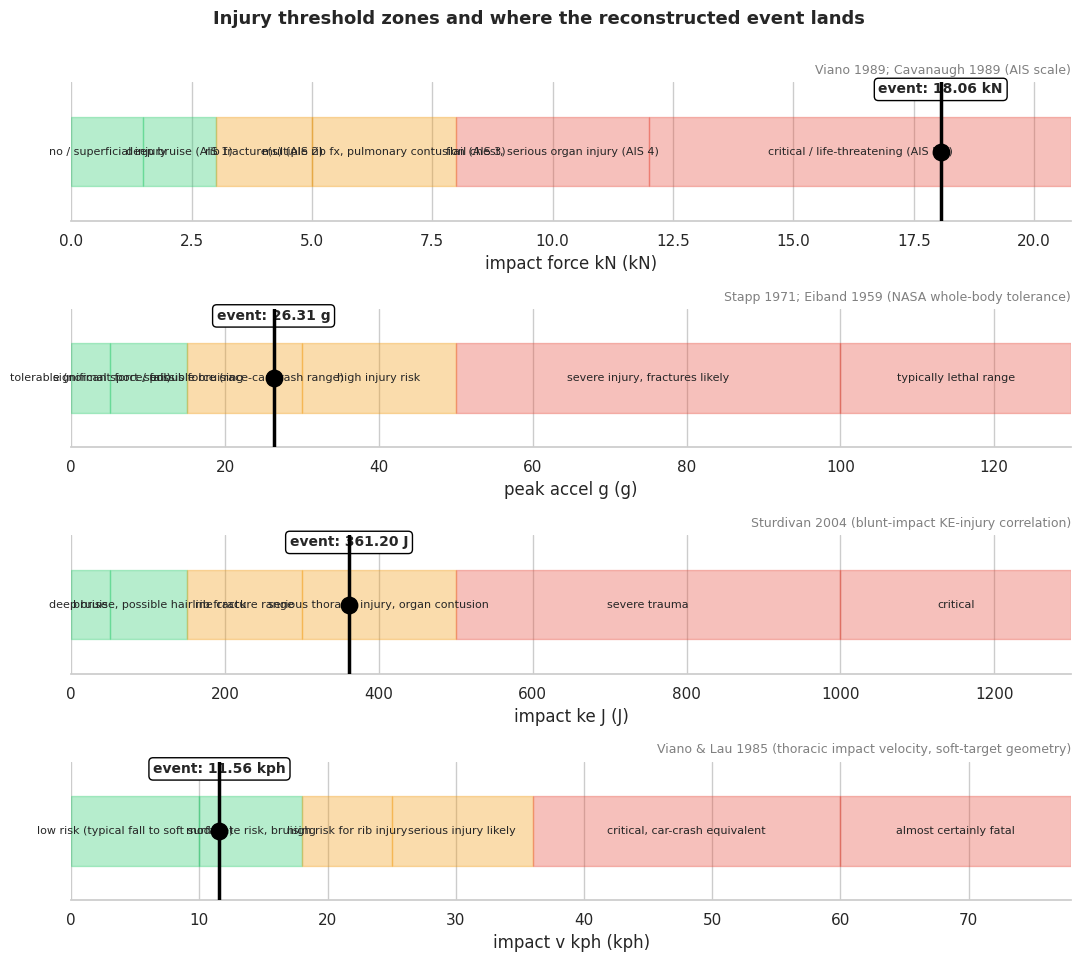

In [20]:
# Visual: per-quantity injury-threshold gradient with the simulation value marked.
fig, axes = plt.subplots(len(INJURY_THRESHOLDS), 1, figsize=(11, 2.4 * len(INJURY_THRESHOLDS)))
if len(INJURY_THRESHOLDS) == 1:
    axes = [axes]

for ax, (key, spec) in zip(axes, INJURY_THRESHOLDS.items()):
    val = sim_values[key]
    bands = spec["bands"]
    finite_uppers = [b[0] for b in bands if b[0] != float("inf")]
    x_max = max(finite_uppers[-1] * 1.3, val * 1.15)

    prev = 0.0
    for upper, label, _rich_color, mpl_color in bands:
        upper_eff = min(upper, x_max) if upper != float("inf") else x_max
        if prev >= x_max:
            break
        ax.axvspan(prev, upper_eff, ymin=0.25, ymax=0.75, color=mpl_color, alpha=0.35)
        mid = (prev + upper_eff) / 2
        ax.text(
            mid, 0.5, label,
            ha="center", va="center", fontsize=8,
            transform=ax.get_xaxis_transform(),
        )
        prev = upper_eff

    # Sim value marker
    ax.axvline(val, color="black", linewidth=2.5, zorder=5)
    ax.scatter(
        [val], [0.5], s=140, color="black", zorder=6,
        transform=ax.get_xaxis_transform(),
    )
    ax.annotate(
        f"event: {val:,.2f} {spec['unit']}",
        xy=(val, 0.92), xycoords=("data", "axes fraction"),
        ha="center", fontsize=10, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"),
    )

    ax.set_xlim(0, x_max)
    ax.set_ylim(0, 1)
    ax.set_yticks([])
    ax.set_xlabel(f"{key.replace('_', ' ')} ({spec['unit']})")
    ax.set_title(spec["source"], fontsize=9, loc="right", color="gray")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

fig.suptitle(
    "Injury threshold zones and where the reconstructed event lands",
    fontsize=13, fontweight="bold", y=1.0,
)
fig.tight_layout()
fig.savefig(FIG_DIR / "01-injury-thresholds.png", dpi=120, bbox_inches="tight")
plt.show()


## Audio signature of the impact

The reconstructed impact deposits the carry-over kinetic energy into the elevator door over ~4 ms. If that event happened, a recording of the visit would contain a distinctive acoustic signature: a sharp peak from the plate impact, followed by the modal ringing of the door panel, the glass window, and the trapped-air cavity. This section predicts the peak SPL range, the dominant frequencies, and how the predicted signal compares to common reference sounds and to a phone microphone's clipping ceiling.

### Door construction (per testimony)

- Panel: 2.0 m x 1.0 m, two 2 mm steel plates 3 cm apart (hollow door)
- Window: 20 cm wide x 60 cm tall vertical glass, 4 mm thickness assumed
- Edge condition: simply supported (standard elevator-frame mounting)

### Physical model

- **Plate modal frequencies** from the Kirchhoff thin-plate equation: $f_{mn} = (\pi/2)\sqrt{D/\sigma}\left((m/a)^2 + (n/b)^2\right)$, with flexural rigidity $D = E h^3 / (12(1-\nu^2))$ and areal density $\sigma = \rho h$
- **Air cavity** between the two steel plates treated as a sealed half-wave resonator: $f = c/(2d)$ with $d = 3$ cm gives ~5.7 kHz, contributing a bright top-end "clang"
- **Peak SPL** from the radiated acoustic power $P_a = \eta\, W / t$ where $W$ is the impact work, $t$ is the contact time, and $\eta$ is the radiation efficiency (bracketed at 0.1%, 1%, and 5% to give an honest range). Sound intensity at the listener $I = P_a / (4\pi r^2)$, and $L_p = 10\log_{10}(I/I_{\text{ref}})$ with $I_{\text{ref}} = 10^{-12}$ W/m²

### Why this is a forensic test

The audio recording at `data/external/event_audio/event_recording.m4a` was on throughout the visit. The predicted peak SPL is at or above what consumer phone microphones can record without clipping (~120 dB SPL peak). If the recording shows no clipping spike, no panel ringing in the predicted frequency bands, and no audible reaction from Cecilia (who was standing in segment 1 with a direct acoustic line-of-sight to the elevator door), the event did not produce the impact this reconstruction predicts.


In [21]:
# === Audio signature of the predicted impact (thin call site - library does the physics) ===
from henryk_simulations.corridor import (
    AcousticSource,
    DEFAULT_ELEVATOR_DOOR,
    REF_SOUNDS,
    frequency_band,
    predict_signature,
)

# Build the source from the impact result already on hand (imp = swap-throw impact).
source = AcousticSource(
    peak_force_N=imp.f_impact,
    stopping_distance_m=imp.stopping_distance,
    contact_time_s=imp.t_stop,
)
prediction = predict_signature(DEFAULT_ELEVATOR_DOOR, source)

# --- Reporting ---
console.rule("[bold medium_purple]Acoustic source quantities")
src = Table(
    title="Impact source",
    box=box.ROUNDED,
    show_header=True,
    header_style="bold medium_purple",
    title_justify="left",
    title_style="bold medium_purple",
)
src.add_column("Quantity", style="bold")
src.add_column("Value", justify="right")
src.add_row("peak impact force",     f"[light_sea_green]{source.peak_force_N/1000:.2f} kN[/light_sea_green]")
src.add_row("stopping distance",     f"[light_sea_green]{source.stopping_distance_m*100:.1f} cm[/light_sea_green]")
src.add_row("contact time",          f"[light_sea_green]{source.contact_time_s*1000:.2f} ms[/light_sea_green]")
src.add_row("impact work deposited", f"[light_sea_green]{source.work_deposited_J:.0f} J[/light_sea_green]")
console.print(src)

console.rule("[bold medium_purple]Resonant frequencies of the door, window, and air cavity")

BAND_PALETTE = {
    "infrasound": "grey70",
    "bass":       "steel_blue",
    "midrange":   "dark_sea_green",
    "treble":     "dark_goldenrod",
    "ultrasound": "indian_red",
}

def render_modes(title, modes):
    t = Table(
        title=title,
        box=box.SIMPLE,
        show_header=True,
        header_style="bold slate_blue1",
        title_justify="left",
    )
    t.add_column("mode (m, n)")
    t.add_column("frequency", justify="right")
    t.add_column("band")
    for mode in modes:
        band = frequency_band(mode.frequency_hz)
        color = BAND_PALETTE[band]
        t.add_row(
            f"({mode.m}, {mode.n})",
            f"[light_sea_green]{mode.frequency_hz:,.1f} Hz[/light_sea_green]",
            f"[{color}]{band}[/{color}]",
        )
    console.print(t)

render_modes("Steel door panel (2 m x 1 m x 2 mm)", prediction.door_modes)
render_modes("Glass window (0.20 m x 0.60 m x 4 mm)", prediction.window_modes)
rprint(
    f"[bold slate_blue1]Cavity (3 cm air gap) first axial mode:[/bold slate_blue1] "
    f"[light_sea_green]{prediction.cavity_axial_hz:,.0f} Hz[/light_sea_green]"
)

console.rule("[bold medium_purple]Predicted peak SPL range")
spl_table = Table(
    title="Sound pressure level (dB re 20 µPa) at the listener",
    box=box.ROUNDED,
    show_header=True,
    header_style="bold medium_purple",
    title_justify="left",
    title_style="bold medium_purple",
)
spl_table.add_column("Listener / distance", style="bold")
for eta_label, eta_val in prediction.eta_range.items():
    spl_table.add_column(f"eta = {eta_val:.3f}\n({eta_label})", justify="right")
for listener_label, _r in prediction.listeners:
    row = [listener_label]
    for eta_label in prediction.eta_range:
        spl = prediction.spl_grid[listener_label][eta_label]
        spl_color = "indian_red" if spl >= 120 else "dark_goldenrod" if spl >= 90 else "dark_sea_green"
        row.append(f"[{spl_color}]{spl:.0f} dB SPL[/{spl_color}]")
    spl_table.add_row(*row)
console.print(spl_table)

ref_t = Table(
    title="Common-reference SPL benchmarks",
    box=box.SIMPLE,
    show_header=True,
    header_style="bold slate_blue1",
    title_justify="left",
)
ref_t.add_column("SPL", justify="right")
ref_t.add_column("Comparable source")
for db, txt in REF_SOUNDS:
    db_color = "indian_red" if db >= 120 else "dark_goldenrod" if db >= 90 else "dark_sea_green"
    ref_t.add_row(f"[{db_color}]{db} dB[/{db_color}]", f"[grey70]{txt}[/grey70]")
console.print(ref_t)

# Forensic-test summary line (one block, semantic colours)
typical_eta_label = list(prediction.eta_range)[len(prediction.eta_range) // 2]
phone_listener_label = prediction.listeners[-1][0]
typical_spl_at_mic = prediction.spl_grid[phone_listener_label][typical_eta_label]
mode_lo = prediction.door_modes[0].frequency_hz
mode_hi = prediction.door_modes[-1].frequency_hz
rprint(
    "\n[bold medium_purple]Forensic test:[/bold medium_purple] at typical radiation efficiency "
    f"([light_sea_green]{prediction.eta_range[typical_eta_label]:.2%}[/light_sea_green]), "
    f"the peak SPL at the phone microphone (~2 m) is "
    f"[bold indian_red]{typical_spl_at_mic:.0f} dB SPL[/bold indian_red]. "
    f"Consumer phone mics clip at ~[dark_goldenrod]120 dB SPL[/dark_goldenrod]. "
    f"If the recording at [cadet_blue]data/external/event_audio/event_recording.m4a[/cadet_blue] "
    f"shows neither a clipping spike nor steel panel ringing in the "
    f"[light_sea_green]{mode_lo:.0f}-{mode_hi:.0f} Hz[/light_sea_green] band, "
    f"the impact this reconstruction predicts did not occur."
)


─────────────────────────────────────────── Acoustic source quantities ────────────────────────────────────────────

Impact source                       
╭───────────────────────┬──────────╮
│ Quantity              │    Value │
├───────────────────────┼──────────┤
│ peak impact force     │ 18.06 kN │
│ stopping distance     │   2.0 cm │
│ contact time          │ 12.45 ms │
│ impact work deposited │    181 J │
╰───────────────────────┴──────────╯

──────────────────────────── Resonant frequencies of the door, window, and air cavity ─────────────────────────────

Steel door panel (2 m x 1 m x 2 mm)     
                                        
  mode (m, n)   frequency   band        
 ────────────────────────────────────── 
  (1, 1)           6.0 Hz   infrasound  
  (2, 1)           9.6 Hz   infrasound  
  (3, 1)          15.6 Hz   infrasound  
  (1, 2)          20.4 Hz   bass        
  (2, 2)          24.0 Hz   bass        
  (4, 1)          24.0 Hz   bass

Glass window (0.20 m x 0.60 m x 4 mm)  
                                       
  mode (m, n)    frequency   band      
 ───────────────────────────────────── 
  (1, 1)          273.3 Hz   midrange  
  (1, 2)          355.3 Hz   midrange  
  (1, 3)          491.9 Hz   midrange  
  (1, 4)          683.2 Hz   midrange  
  (2, 1)        1,011.2 Hz   midrange  
  (2, 2)        1,093.2 Hz   midrange

Cavity (3 cm air gap) first axial mode: 5,717 Hz

──────────────────────────────────────────── Predicted peak SPL range ─────────────────────────────────────────────

Sound pressure level (dB re 20 µPa) at the listener                                     
╭───────────────────────┬────────────────────────┬─────────────┬───────────────────────╮
│                       │            eta = 0.001 │ eta = 0.010 │           eta = 0.050 │
│ Listener / distance   │ (low (lossy mounting)) │   (typical) │ (high (well-coupled)) │
├───────────────────────┼────────────────────────┼─────────────┼───────────────────────┤
│ door surface (~10 cm) │             141 dB SPL │  151 dB SPL │            158 dB SPL │
│ Cecilia at ~1.5 m     │             117 dB SPL │  127 dB SPL │            134 dB SPL │
│ phone mic at ~2 m     │             115 dB SPL │  125 dB SPL │            132 dB SPL │
╰───────────────────────┴────────────────────────┴─────────────┴───────────────────────╯

Common-reference SPL benchmarks                    
                                                   
     SPL   Comparable source                       
 ───────────────────────────────────────────────── 
   60 dB   normal conversation at 1 m              
   90 dB   lawn mower at 1 m                       
  110 dB   rock concert, front row                 
  120 dB   pain threshold; phone-mic clipping      
  130 dB   jackhammer at 1 m                       
  140 dB   jet engine at 30 m; gunshot at 5 m      
  160 dB   gunshot at 1 m; instant hearing damage

Forensic test: at typical radiation efficiency (1.00%), the peak SPL at the phone microphone (~2 m) is 125 dB SPL. 
Consumer phone mics clip at ~120 dB SPL. If the recording at data/external/event_audio/event_recording.m4a shows 
neither a clipping spike nor steel panel ringing in the 6-24 Hz band, the impact this reconstruction predicts did 
not occur.

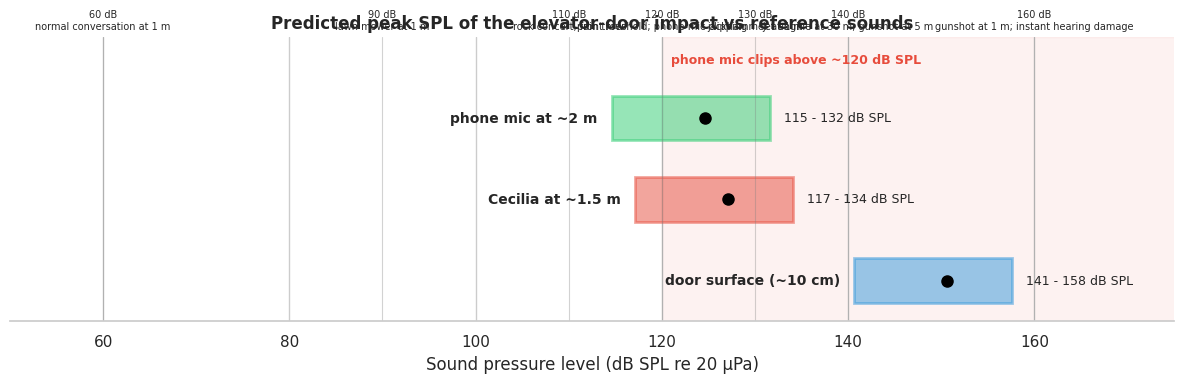

In [22]:
# Visualisation - delegated to the library (henryk_simulations.corridor.plots).
from henryk_simulations.corridor.plots import plot_audio_signature

fig_audio = plot_audio_signature(
    prediction,
    out_path=FIG_DIR / "01-audio-signature.png",
)
plt.show()


## Summary

Refer to `reports/corridor-plausibility.md` for the narrative verdict and embedded figures. The per-phase scores and kinematic table are written to `reports/01-phase-scores.csv` and `reports/01-phase-kinematics.csv` for downstream use.

### Limitations

- Constant-acceleration (triangular velocity) profile per phase is the most charitable interpretation; smoother profiles would require higher peaks.
- Resistance model is a friction-equivalent + constant brake; it does not capture active resistance (lowering centre of mass, bracing, counter-rotation).
- Reference distributions are normal with adult male means and SDs; tail probabilities should be read as approximate.
- The analysis is purely kinematic plausibility against population biomechanics. It does not constitute a forensic conclusion about any specific event.
